<a href="https://colab.research.google.com/github/rodhipranoto/pbi-homecreditrisk/blob/main/finaltask_homecredit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. LOAD DATA

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import pandas as pd
import numpy as np
path = '/content/drive/MyDrive/Data science/PBI - Rakamin/home-credit-default-risk/'


app_train = pd.read_csv(path + 'application_train.csv')
app_test = pd.read_csv(path + 'application_test.csv')
bureau = pd.read_csv(path + 'bureau.csv')
bureau_balance = pd.read_csv(path + 'bureau_balance.csv')
previous = pd.read_csv(path + 'previous_application.csv')
installments = pd.read_csv(path + 'installments_payments.csv')
credit_card = pd.read_csv(path + 'credit_card_balance.csv')
pos_cash = pd.read_csv(path + 'POS_CASH_balance.csv')
sample_submission = pd.read_csv(path + 'sample_submission.csv')
desc = pd.read_csv(path + 'HomeCredit_columns_description.csv', encoding='latin-1')


In [8]:
installments['LATE_PAYMENT'] = installments['DAYS_ENTRY_PAYMENT'] - installments['DAYS_INSTALMENT']

late_payment = installments.groupby('SK_ID_CURR')['LATE_PAYMENT'].mean().reset_index()
late_payment.rename(columns={'LATE_PAYMENT': 'LATE_PAYMENT_mean'}, inplace=True)

In [9]:
df = app_train.merge(late_payment, on='SK_ID_CURR', how='left')

In [10]:
df['DEBT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

#2. PREPROCESSING

In [11]:
import numpy as np

X = df.drop(['TARGET', 'SK_ID_CURR'], axis=1)
y = df['TARGET']

# clean data
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

#3. SPLIT DATA

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#4. HANDLE IMBALANCE

In [13]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

#5.MODELING

In [15]:
X = pd.get_dummies(X)

In [16]:
import numpy as np

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [18]:
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [19]:
from sklearn.metrics import roc_auc_score

y_prob = xgb.predict_proba(X_test)[:,1]
roc_auc_score(y_test, y_prob)

np.float64(0.759102439706977)

#6.EVALUATION

In [20]:
from sklearn.metrics import roc_auc_score

y_prob = xgb.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, y_prob)

print("AUC:", auc)

AUC: 0.759102439706977


#7. FEATURE IMPORTANCE

In [21]:
import pandas as pd

importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb.feature_importances_
}).sort_values(by='importance', ascending=False)

importance.head(10)

,feature,importance
29,EXT_SOURCE_3,0.052991
28,EXT_SOURCE_2,0.044640
132,NAME_EDUCATION_TYPE_Higher education,0.023839
126,NAME_INCOME_TYPE_Pensioner,0.019336
108,CODE_GENDER_F,0.017793
109,CODE_GENDER_M,0.017615
130,NAME_INCOME_TYPE_Working,0.016019
27,EXT_SOURCE_1,0.015083
79,FLAG_DOCUMENT_3,0.013919
111,FLAG_OWN_CAR_N,0.013631


#8. VISUAL INSIGHT

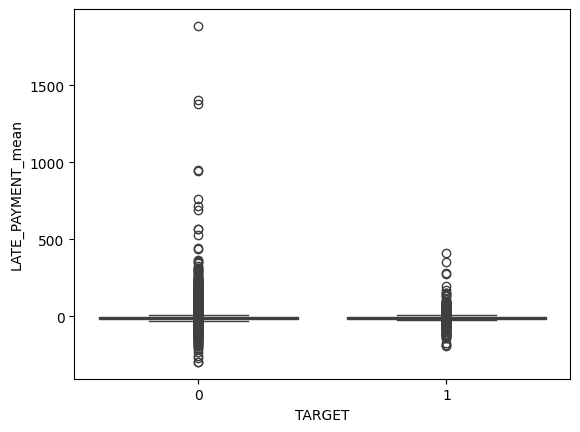

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='TARGET', y='LATE_PAYMENT_mean', data=df)
plt.show()